# Spam / Phishing Email Detection using Machine Learning

**Course:** Artificial Intelligence  
**Academic Year:** 2025-2026  
**Instructor:** Pr. Soufiane HAMIDA  

**Team Members:**
- Mohamed Reda El Ghazouani
- Anass Bentaib
- Chahin Boudra
- Youssef Saoud


## Introduction

Email is one of the most widely used communication tools in personal, academic, and professional life. However, email systems are also frequently targeted by spam and phishing messages. These unwanted emails may advertise suspicious products, attempt to steal personal information, or mislead users into clicking harmful links.

In this project, we build a simple machine learning system that can classify emails into two categories:
- **Ham (0):** a normal and legitimate email
- **Spam (1):** an unwanted or suspicious email

The goal of this work is to demonstrate a complete and beginner-friendly artificial intelligence pipeline, including data exploration, preprocessing, feature extraction, model training, evaluation, and custom prediction.

## Problem Statement

The main problem addressed in this project is the automatic detection of spam or phishing-like emails from their text content.

Manually checking every email is not practical when the number of messages becomes large. For this reason, machine learning can be used to learn patterns from previously labeled emails and then predict whether a new message is likely to be spam or not.

Our objective is to train simple and interpretable models suitable for a first AI course, without using deep learning or advanced natural language processing methods.

## Import Libraries

The following libraries are used in this notebook:
- `pandas` and `numpy` for data handling
- `matplotlib` and `seaborn` for visualization
- `scikit-learn` for splitting the data, converting text into features, training models, and evaluating results

In [32]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Dataset Description

The dataset used in this project is stored in `emails.csv` and contains two columns:
- `text`: the content of the email
- `spam`: the class label, where `1` means spam and `0` means ham

This dataset is appropriate for a beginner machine learning project because it provides labeled text examples that can be used to train and test classification models.

In [35]:
file_path = "/emails.csv"
backup_url = "https://raw.githubusercontent.com/iiMedR/spam_email_detection_notebook/main/emails.csv"

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    df = pd.read_csv(backup_url)

df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


## Exploratory Data Analysis (EDA)

Before training a model, it is important to understand the dataset. In this section, we inspect the size of the data, look for missing values, and study the distribution of the target classes.

This step helps us identify potential issues and better understand what the model will learn from.

In [39]:
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["spam"].value_counts())

Dataset shape: (5728, 2)

First 5 rows:


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1



Missing values:
text    0
spam    0
dtype: int64

Class distribution:
spam
0    4360
1    1368
Name: count, dtype: int64


/tmp/ipykernel_14134/3093246943.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="spam", data=df, palette="Set2")


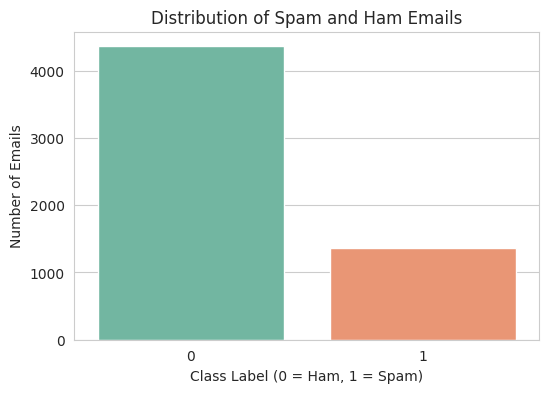

In [40]:
plt.figure(figsize=(6, 4))
sns.countplot(x="spam", data=df, palette="Set2")
plt.title("Distribution of Spam and Ham Emails")
plt.xlabel("Class Label (0 = Ham, 1 = Spam)")
plt.ylabel("Number of Emails")
plt.show()

**Interpretation:** This graph shows how many emails belong to each class. Understanding the class balance is important because highly imbalanced data may affect model performance.

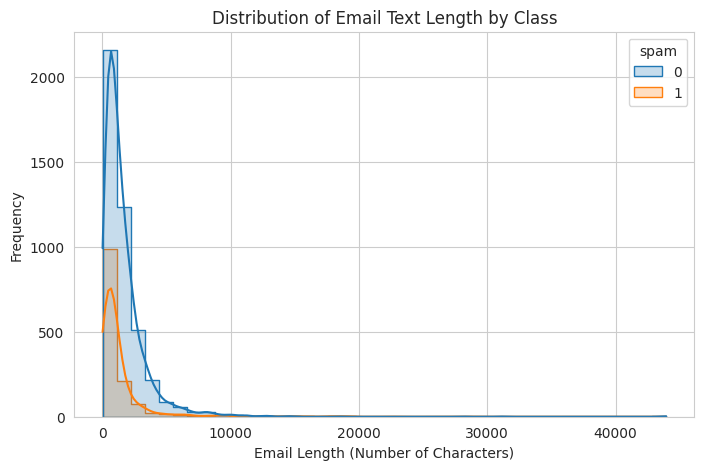

In [41]:
df["text"] = df["text"].fillna("")
df["text_length"] = df["text"].apply(len)

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="text_length", hue="spam", bins=40, kde=True, element="step")
plt.title("Distribution of Email Text Length by Class")
plt.xlabel("Email Length (Number of Characters)")
plt.ylabel("Frequency")
plt.show()

**Interpretation:** This plot compares the lengths of ham and spam emails. In many text classification tasks, message length can provide useful information because spam emails may follow different writing patterns from normal emails.

/tmp/ipykernel_14134/65255160.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_counts.values, y=word_counts.index, palette="viridis")


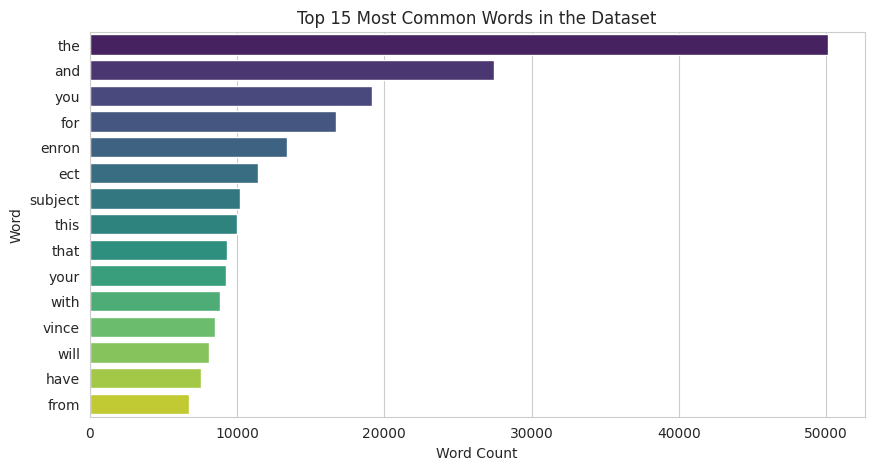

In [42]:
all_text = " ".join(df["text"].astype(str)).lower()
words = re.findall(r"\b[a-z]{3,}\b", all_text)
word_counts = pd.Series(words).value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=word_counts.values, y=word_counts.index, palette="viridis")
plt.title("Top 15 Most Common Words in the Dataset")
plt.xlabel("Word Count")
plt.ylabel("Word")
plt.show()

**Interpretation:** This graph gives a simple overview of frequently appearing words in the dataset. It is not enough for classification by itself, but it helps us understand the general vocabulary used in the emails.

## Data Preprocessing

Raw email text usually contains inconsistencies such as uppercase and lowercase variations, extra spaces, and possible missing values. Before using the text for machine learning, we apply simple preprocessing steps:
- convert text to lowercase
- remove unnecessary spaces
- handle missing values

These operations make the input cleaner and more consistent for the model.

In [44]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head()

,text,clean_text
0,Subject: naturally irresistible your corporate...,subject: naturally irresistible your corporate...
1,Subject: the stock trading gunslinger fanny i...,subject: the stock trading gunslinger fanny is...
2,Subject: unbelievable new homes made easy im ...,subject: unbelievable new homes made easy im w...
3,Subject: 4 color printing special request add...,subject: 4 color printing special request addi...
4,"Subject: do not have money , get software cds ...","subject: do not have money , get software cds ..."


## Train-Test Split

To evaluate the model fairly, the dataset must be divided into training data and testing data.

- The **training set** is used to teach the model.
- The **testing set** is used to evaluate how well the model performs on unseen data.

We use `shuffle=True` because the dataset may not be randomly ordered, and `stratify=y` to preserve the class proportions in both sets.

In [45]:
X = df["clean_text"]
y = df["spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    stratify=y,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4582
Testing samples: 1146


## Feature Extraction

Machine learning models cannot directly understand raw text, so we must convert the email content into numerical features.

For this project, we use **TF-IDF (Term Frequency-Inverse Document Frequency)**. TF-IDF gives higher importance to words that are informative in a message and lower importance to words that appear too frequently everywhere.

This is a simple and popular technique for beginner text classification projects.

In [46]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (4582, 5000)
X_test_tfidf shape: (1146, 5000)


## Model Training

In this project, we train two simple machine learning models:

1. **Multinomial Naive Bayes**
   This model is widely used in text classification because it is fast, simple, and often performs well on bag-of-words or TF-IDF features.

2. **Logistic Regression**
   This is another common classification model. It is still simple enough for a beginner project and provides a useful comparison with Naive Bayes.

In [47]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

## Model Evaluation

To judge the quality of the models, we use several evaluation metrics:

- **Accuracy:** the proportion of correct predictions among all predictions.
- **Precision:** among the emails predicted as spam, how many were actually spam.
- **Recall:** among the actual spam emails, how many were correctly detected.
- **F1-Score:** a balanced measure that combines precision and recall.

These metrics are useful because in spam detection, it is not enough to only look at accuracy. A good model should also correctly identify spam while minimizing incorrect classifications.

In [48]:
def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

nb_results = evaluate_model(y_test, y_pred_nb)
lr_results = evaluate_model(y_test, y_pred_lr)

results_df = pd.DataFrame([
    {"Model": "Multinomial Naive Bayes", **nb_results},
    {"Model": "Logistic Regression", **lr_results}
])

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.980803,0.973684,0.945255,0.959259
1,Logistic Regression,0.983421,0.984791,0.945255,0.964618


In [49]:
print("Classification Report - Multinomial Naive Bayes\n")
print(classification_report(y_test, y_pred_nb, target_names=["Ham", "Spam"]))

print("\nClassification Report - Logistic Regression\n")
print(classification_report(y_test, y_pred_lr, target_names=["Ham", "Spam"]))

Classification Report - Multinomial Naive Bayes

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       872
        Spam       0.97      0.95      0.96       274

    accuracy                           0.98      1146
   macro avg       0.98      0.97      0.97      1146
weighted avg       0.98      0.98      0.98      1146


Classification Report - Logistic Regression

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       872
        Spam       0.98      0.95      0.96       274

    accuracy                           0.98      1146
   macro avg       0.98      0.97      0.98      1146
weighted avg       0.98      0.98      0.98      1146



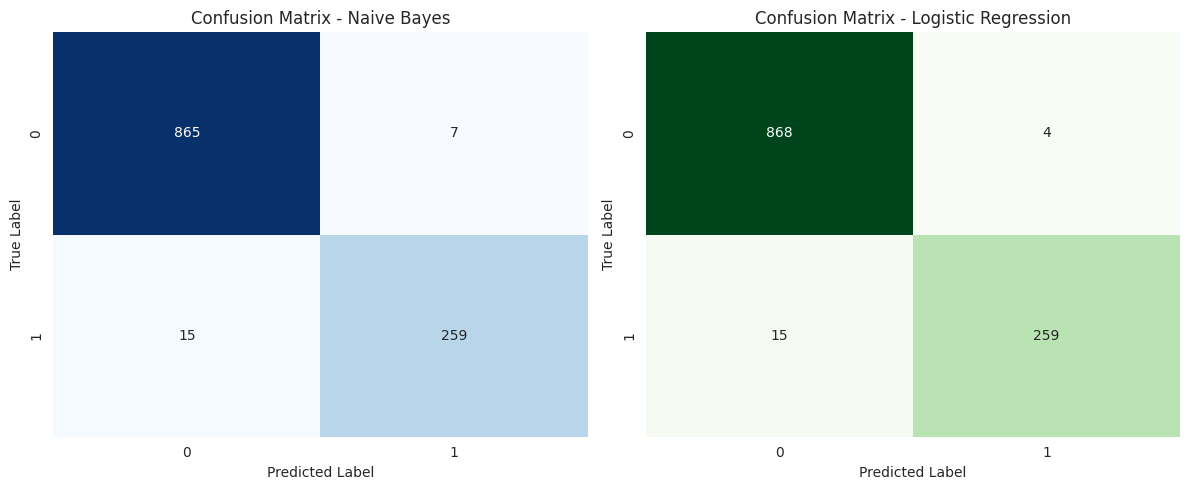

In [50]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Confusion Matrix - Naive Bayes")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("Confusion Matrix - Logistic Regression")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

**Interpretation:** A confusion matrix shows how many predictions were correct or incorrect for each class. It helps us understand whether the model is confusing ham with spam or spam with ham.

## Results Discussion

The comparison table above allows us to observe which model performs better on this dataset. Since both models use the same TF-IDF features, any difference in performance comes mainly from the learning algorithm itself.

In many text classification tasks, Multinomial Naive Bayes provides strong baseline results because it is designed for word-frequency-based representations. Logistic Regression may also perform very well and can sometimes offer a better balance between precision and recall.

The best model for this project should be selected based on the evaluation metrics, especially if one model detects spam more reliably while keeping false alarms at a reasonable level.

## Custom Email Prediction Demo

The following cell allows the user to test the trained model on a custom email message. The message is cleaned, converted into TF-IDF features, and then classified as either **Spam** or **Ham**.

In [51]:
custom_email = """
Congratulations! You have won a free gift card. Click the link now to claim your prize.
"""

custom_email_clean = clean_text(custom_email)
custom_email_tfidf = vectorizer.transform([custom_email_clean])

prediction = nb_model.predict(custom_email_tfidf)[0]
prediction_proba = nb_model.predict_proba(custom_email_tfidf)[0]

label = "Spam" if prediction == 1 else "Ham"

print("Custom email text:\n")
print(custom_email)
print("Prediction:", label)
print("Probability [Ham, Spam]:", prediction_proba)

Custom email text:


Congratulations! You have won a free gift card. Click the link now to claim your prize.

Prediction: Spam
Probability [Ham, Spam]: [0.15144632 0.84855368]


## Project Limitations

Although this project demonstrates a complete machine learning pipeline, it has several limitations:

- **Dataset quality:** the model can only learn from the examples available in the dataset. If the dataset contains noisy text, repeated patterns, or unrepresentative samples, the model may not generalize perfectly.
- **Possible false positives:** some legitimate emails may contain promotional or urgent language and could be incorrectly classified as spam.
- **Limited scope of a student project:** this work uses simple preprocessing and classical machine learning models, which is appropriate for a first AI course but not a complete industrial solution.
- **Future improvements:** better text cleaning, larger and more diverse datasets, n-gram features, model tuning, and more detailed phishing-specific analysis could improve results.

## Conclusion

In this project, we built a complete beginner-level machine learning system for spam and phishing email detection. Starting from a labeled dataset, we explored the data, cleaned the text, converted it into TF-IDF features, trained two classification models, and evaluated their performance using standard metrics.

The results show that machine learning can be useful for automatically identifying suspicious emails. Even with simple models such as Multinomial Naive Bayes and Logistic Regression, it is possible to achieve meaningful classification results.

This project demonstrates the value of artificial intelligence in solving practical problems such as email filtering. It also illustrates the main stages of an AI pipeline in a clear and accessible way suitable for a first university-level course.